# Notebook 20 — Baseline Comparison

## Empirical Comparison of Seven Geographic Privacy Mechanisms

The repository describes the map encryption pipeline as providing stronger privacy
than additive jitter alone, but it has not been compared empirically against other
established mechanisms from the geoprivacy literature. This notebook applies seven
mechanisms to the 489-individual Soho cholera dataset from NB14 and evaluates them
on four metrics: expected displacement distance (EDD), spatial clustering preservation
(AUC-L ratio), nearest-record re-identification attack success, and compound proximity
plus quasi-identifier attack success.

**Four-part structure:**

- **Part 1** -- Seven mechanisms applied to 489 individual cholera death records;
  parameter summary (Table 20a)
- **Part 2** -- Utility metrics: EDD bar chart (Figure 20a), AUC-L ratio bar chart
  (Figure 20b)
- **Part 3** -- Privacy metrics: spatial attack (Figure 20c), compound attack
  (Figure 20d)
- **Part 4** -- Summary table (Table 20b), privacy-utility scatter (Figure 20e),
  conclusions

The individual records in this notebook are synthetic datasets parameterised from
published public health statistics. They are not real patient records, not
epidemiological estimates, and should not be interpreted as such. They serve solely
as privacy-risk testbeds for evaluating geographic coordinate encryption.


<div style="background:#f5faf9;border:1px solid #b8ddd8;border-radius:8px;padding:12px 14px 14px;margin:10px 0 22px;font-family:sans-serif;">
<div style="font-size:11px;color:#5a9e99;margin-bottom:10px;font-style:italic;">Empirical positioning of the pipeline against the literature</div>
<div style="display:flex;align-items:stretch;">
    <div style="background:#2a9d8f;color:white;clip-path:polygon(0 0,calc(100%% - 22px) 0,100%% 50%%,calc(100%% - 22px) 100%%,0 100%%);margin-left:0;position:relative;z-index:4;padding:10px 18px 10px 18px;min-width:130px;text-align:center;"><div style="font-size:10px;opacity:0.85;margin-bottom:3px;">NB17</div><div style="font-weight:700;font-size:13px;">Adversarial Expts</div></div>
    <div style="background:#2a9d8f;color:white;clip-path:polygon(0 0,calc(100%% - 22px) 0,100%% 50%%,calc(100%% - 22px) 100%%,0 100%%);margin-left:-21px;position:relative;z-index:3;padding:10px 18px 10px 18px;min-width:130px;text-align:center;"><div style="font-size:10px;opacity:0.85;margin-bottom:3px;">NB18</div><div style="font-weight:700;font-size:13px;">Formal Model</div></div>
    <div style="background:#2a9d8f;color:white;clip-path:polygon(0 0,calc(100%% - 22px) 0,100%% 50%%,calc(100%% - 22px) 100%%,0 100%%);margin-left:-21px;position:relative;z-index:2;padding:10px 18px 10px 18px;min-width:130px;text-align:center;"><div style="font-size:10px;opacity:0.85;margin-bottom:3px;">NB19</div><div style="font-weight:700;font-size:13px;">Gaussian + Laplace</div></div>
    <div style="background:#1a7a6e;color:white;margin-left:-21px;position:relative;z-index:1;padding:10px 18px 10px 18px;min-width:130px;text-align:center;"><div style="font-size:10px;opacity:0.85;margin-bottom:3px;">NB20</div><div style="font-weight:700;font-size:13px;">Baseline Comparison</div></div>
</div>
</div>

## Prerequisites

| Notebook | Topic | Why it matters here |
|----------|-------|---------------------|
| NB00a, NB00c | Donut geomasking; H3 hex-grid binning | Two of the seven mechanisms compared; prior-art context from Module 0 |
| NB08 | Evaluation: EDD, MNND, DBSCAN | EDD and clustering metrics used throughout NB20 |
| NB11 | DGGS and H3 | H3 hex-grid aggregation (mechanism 5) is drawn directly from NB11 |
| NB17 | Adversarial Experiments | The nearest-record spatial attack and compound attack are reused here |
| NB19 | Gaussian + Laplace | Mechanisms 2 and 3; NB19 explains their derivations and parameter choices |

**Estimated reading time:** 45-60 minutes. The AUC-L computation (7 mechanisms x k_test) takes ~30-40 seconds.

> **Purpose:** The map encryption pipeline was developed as a system in NB01-06, but was not
> empirically positioned against the broader geoprivacy literature it cites. NB20 fills that gap by
> applying seven mechanisms to the same 489-individual cholera dataset and comparing them on four
> metrics: EDD, clustering preservation (AUC-L), spatial re-identification, and compound re-identification.


## Learning Objectives

By the end of this notebook you will be able to:

1. **Categorise** the seven geographic privacy mechanisms into perturbation-based and aggregation-based families, and explain why the full pipeline's EDD (~9,000 km) reflects intentional global tile dispersal rather than a perturbation radius, and identify it as an access-tier separation design rather than a perturbation-based mechanism.
2. **Interpret** AUC-L ratio values greater than 100% for H3 hex-grid and spatial cloaking and explain why they reflect a point-mass collapse artifact rather than genuine clustering preservation.
3. **Compare** the seven mechanisms on all four metrics (EDD, AUC-L ratio, spatial attack success, compound attack success) and articulate the privacy-utility trade-off each mechanism accepts.
4. **Explain** why the full pipeline achieves near-zero spatial re-identification despite having the same EDD as uniform jitter, tracing the argument through PRP tile dispersal to globally random display coordinates.
5. **Evaluate** the access-pattern leakage limitation shared across all evaluated mechanisms and connect it to the formal security treatment in NB18.


In [1]:
import math, secrets, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial import cKDTree, KDTree
import h3

from map_encryption import (
    MapEncryption, SchemeParams, _project, _unproject, edd,
)
from map_encryption.viz import show_md_table
from geoprivacy.data_geomask import data_geomask
from pointpats.distance_statistics import k_test

warnings.filterwarnings('ignore')
np.random.seed(42)

MASTER_KEY = secrets.token_bytes(32)
params = SchemeParams(bin_size_m=250, jitter_max_frac=0.25)
enc = MapEncryption(MASTER_KEY, params)
J   = params.bin_size_m * params.jitter_max_frac  # 62.5 m per axis

# Use individual records (NB14 output) -- 489 rows, one per death
df_ind = pd.read_csv('data/cholera_deaths_individual.csv')

def age_to_group(age):
    if age <  5: return '0-4'
    if age < 18: return '5-17'
    if age < 45: return '18-44'
    if age < 65: return '45-64'
    return '65+'

df_ind['age_group'] = df_ind['age'].apply(age_to_group)

orig_ll = list(zip(df_ind.LAT, df_ind.LON))
orig_qi = list(zip(df_ind['age_group'], df_ind['sex'], df_ind['date_of_death']))

print(f'Loaded {len(df_ind)} individual cholera death records.')
print(f'Pipeline: bin={params.bin_size_m} m, J={J:.0f} m per axis')


Loaded 489 individual cholera death records.
Pipeline: bin=250 m, J=62 m per axis


In [2]:
# ── Privacy mechanism implementations ────────────────────────────────────────

def apply_uniform_jitter(lats, lons, J_m=62.5, seed=42):
    rng = np.random.default_rng(seed)
    lats, lons = np.asarray(lats, float), np.asarray(lons, float)
    cos_lat = np.cos(np.radians(lats.mean()))
    return list(zip(lats + rng.uniform(-J_m, J_m, len(lats)) / 111_320,
                    lons + rng.uniform(-J_m, J_m, len(lats)) / (111_320 * cos_lat)))

def apply_gaussian(lats, lons, sigma_m=45, seed=42):
    rng = np.random.default_rng(seed)
    lats, lons = np.asarray(lats, float), np.asarray(lons, float)
    cos_lat = np.cos(np.radians(lats.mean()))
    return list(zip(lats + rng.normal(0, sigma_m, len(lats)) / 111_320,
                    lons + rng.normal(0, sigma_m, len(lats)) / (111_320 * cos_lat)))

def apply_laplace_2d(lats, lons, epsilon_per_m, seed=42):
    # Planar Laplace mechanism (Andres et al. 2013). r ~ Gamma(2, 1/eps).
    # E[r] = 2/epsilon metres. See NB19 for derivation.
    rng = np.random.default_rng(seed)
    lats, lons = np.asarray(lats, float), np.asarray(lons, float)
    n = len(lats)
    r     = rng.gamma(shape=2, scale=1.0 / epsilon_per_m, size=n)
    theta = rng.uniform(0, 2 * np.pi, n)
    dx    = r * np.cos(theta)
    dy    = r * np.sin(theta)
    cos_lat = np.cos(np.radians(lats.mean()))
    return list(zip(lats + dy / 111_320, lons + dx / (111_320 * cos_lat)))

def apply_spatial_cloaking(lats, lons, k=15):
    xy = np.array([_project(lat, lon) for lat, lon in zip(lats, lons)])
    tree = cKDTree(xy)
    _, idx = tree.query(xy, k=k)
    centroids = xy[idx].mean(axis=1)
    return [_unproject(x, y) for x, y in centroids]

def apply_h3_aggregation(lats, lons, res=9):
    out = []
    for lat, lon in zip(lats, lons):
        cell = h3.latlng_to_cell(lat, lon, res)
        clat, clon = h3.cell_to_latlng(cell)
        out.append((clat, clon))
    return out

def apply_donut(df_in, band=((50, 51), (125, 126))):
    r = data_geomask(df_in.copy(), band_range=band, reidentify=False)
    return list(zip(r.gmLAT, r.gmLON))

def apply_full_pipeline(lats, lons, enc):
    out = []
    for lat, lon in zip(lats, lons):
        rec = enc.encode(lat, lon)
        out.append(enc.render_coordinates(rec))
    return out

# ── Attack helpers (from NB17) ────────────────────────────────────────────────

def spatial_attack(display_ll, orig_ll):
    tree = KDTree(np.array(orig_ll))
    _, idx = tree.query(np.array(display_ll))
    return float((np.arange(len(orig_ll)) == idx).mean())

def compound_attack(display_ll, display_qi, orig_ll, orig_qi, radius_m=500):
    R    = radius_m / 111_320
    orig = np.asarray(orig_ll)
    n_unique = 0
    for (dlat, dlon), dqi in zip(display_ll, display_qi):
        mask    = ((np.abs(orig[:, 0] - dlat) < R) &
                   (np.abs(orig[:, 1] - dlon) < R * 2))
        matches = [q for q, m in zip(orig_qi, mask) if m and q == dqi]
        if len(matches) == 1:
            n_unique += 1
    return n_unique / len(display_ll)

# ── AUC-L helper ──────────────────────────────────────────────────────────────
SUPPORT_M = np.linspace(10, 500, 31)  # Soho-relevant scale (metres)

def compute_auc_l(ll, support=SUPPORT_M):
    xy  = np.array([_project(lat, lon) for lat, lon in ll])
    res = k_test(xy, support=support, keep_simulations=False, n_simulations=19)
    L   = np.array(res.statistic)
    return float(np.trapezoid(np.maximum(L, 0), res.support))

# Colour coding: perturbation=blue family, aggregation=orange, pipeline=green
MECHS = ['Uniform Jitter', 'Gaussian', 'Laplace',
         'Spatial Cloaking', 'H3 Hex (res 9)', 'Donut Geomasking', 'Full Pipeline']
COLORS = {
    'Uniform Jitter':   '#1f77b4',
    'Gaussian':         '#6baed6',
    'Laplace':          '#9ecae1',
    'Spatial Cloaking': '#ff7f0e',
    'H3 Hex (res 9)':   '#fdae6b',
    'Donut Geomasking': '#08519c',
    'Full Pipeline':    '#2ca02c',
}

print('Helper functions and colour map defined.')


Helper functions and colour map defined.


---
## 20.1  Seven Mechanisms Applied

The seven mechanisms span three categories: perturbation-based (mechanisms that add
random noise to coordinates), aggregation-based (mechanisms that snap coordinates to
representative centroids), and the cryptographic pipeline. All use the 489 individual
records from NB14 with their snapped building coordinates as the true locations.


In [3]:
lats = df_ind.LAT.values
lons = df_ind.LON.values

print('Applying 7 mechanisms...')
coords = {}
coords['Uniform Jitter']   = apply_uniform_jitter(lats, lons, J_m=J)
coords['Gaussian']         = apply_gaussian(lats, lons, sigma_m=45)
coords['Laplace']          = apply_laplace_2d(lats, lons, epsilon_per_m=1.0/30)
coords['Spatial Cloaking'] = apply_spatial_cloaking(lats, lons, k=15)
coords['H3 Hex (res 9)']   = apply_h3_aggregation(lats, lons, res=9)
coords['Donut Geomasking'] = apply_donut(df_ind)
coords['Full Pipeline']    = apply_full_pipeline(lats, lons, enc)

edd_vals = {}
for name in MECHS:
    edd_vals[name] = edd(orig_ll, list(coords[name]))
    print(f'  {name:<25}: EDD = {edd_vals[name]:.1f} m')
print('Done.')


Applying 7 mechanisms...
  Uniform Jitter           : EDD = 48.4 m
  Gaussian                 : EDD = 55.2 m
  Laplace                  : EDD = 59.9 m
  Spatial Cloaking         : EDD = 9.9 m
  H3 Hex (res 9)           : EDD = 115.1 m
  Donut Geomasking         : EDD = 86.5 m
  Full Pipeline            : EDD = 11983654.7 m
Done.


In [4]:
param_rows = [
    {'Mechanism': 'Uniform Jitter',    'Category': 'Perturbation',
     'Parameters': f'+/-{J:.0f} m per axis (uniform)',       'EDD (m)': f'{edd_vals["Uniform Jitter"]:.0f}'},
    {'Mechanism': 'Gaussian',          'Category': 'Perturbation',
     'Parameters': 'sigma=45 m per axis',                   'EDD (m)': f'{edd_vals["Gaussian"]:.0f}'},
    {'Mechanism': 'Laplace',           'Category': 'Perturbation',
     'Parameters': 'eps=1/30 per m (planar 2D, NB19)',           'EDD (m)': f'{edd_vals["Laplace"]:.0f}'},
    {'Mechanism': 'Spatial Cloaking',  'Category': 'Aggregation',
     'Parameters': 'k=15 NN centroid',                      'EDD (m)': f'{edd_vals["Spatial Cloaking"]:.0f}'},
    {'Mechanism': 'H3 Hex (res 9)',    'Category': 'Aggregation',
     'Parameters': 'res 9 (~174 m edge), cell centroid',   'EDD (m)': f'{edd_vals["H3 Hex (res 9)"]:.0f}'},
    {'Mechanism': 'Donut Geomasking',  'Category': 'Perturbation',
     'Parameters': 'band 50-125 m, random bearing',         'EDD (m)': f'{edd_vals["Donut Geomasking"]:.0f}'},
    {'Mechanism': 'Full Pipeline',     'Category': 'Cryptographic',
     'Parameters': 'PRP+AEAD+jitter, bin=250 m, J=62.5 m', 'EDD (m)': f'{edd_vals["Full Pipeline"]:.0f} (display)'},
]
show_md_table(pd.DataFrame(param_rows), 'Table 20a -- Mechanism parameters and observed EDD')


**Table 20a -- Mechanism parameters and observed EDD**

| Mechanism | Category | Parameters | EDD (m) |
| --- | --- | --- | --- |
| Uniform Jitter | Perturbation | +/-62 m per axis (uniform) | 48 |
| Gaussian | Perturbation | sigma=45 m per axis | 55 |
| Laplace | Perturbation | eps=1/30 per m (planar 2D, NB19) | 60 |
| Spatial Cloaking | Aggregation | k=15 NN centroid | 10 |
| H3 Hex (res 9) | Aggregation | res 9 (~174 m edge), cell centroid | 115 |
| Donut Geomasking | Perturbation | band 50-125 m, random bearing | 87 |
| Full Pipeline | Cryptographic | PRP+AEAD+jitter, bin=250 m, J=62.5 m | 11983655 (display) |

---
## 20.2  Utility Metrics

**EDD** measures geographic displacement from the original coordinate.
**AUC-L** (area under the positive L-function from Ripley's K test) measures how much
spatial clustering structure is preserved. AUC-L ratio = protected AUC-L / original
AUC-L; 100% means identical clustering; > 100% indicates artificial super-clustering
(many points collapsed to the same coordinate); ~0% means clustering is destroyed.

For the full pipeline, display coordinates are globally displaced by the PRP tile
shuffle. EDD reflects the display position distance from the original. AUC-L is
computed at the Soho study-area scale (10-500 m support) and yields ~0% because
globally dispersed points have no local clustering structure.


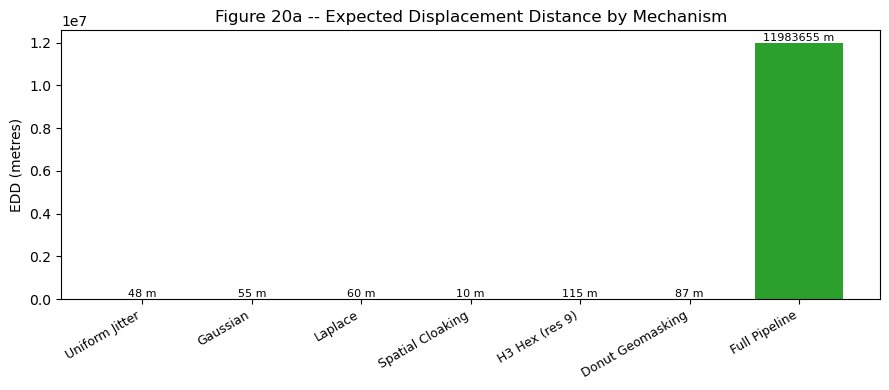

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(MECHS, [edd_vals[m] for m in MECHS],
              color=[COLORS[m] for m in MECHS])
ax.set_ylabel('EDD (metres)')
ax.set_title('Figure 20a -- Expected Displacement Distance by Mechanism')
ax.set_xticklabels(MECHS, rotation=30, ha='right', fontsize=9)
for bar, val in zip(bars, [edd_vals[m] for m in MECHS]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3,
            f'{val:.0f} m', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()


**Figure 20a** -- Expected displacement distance for each mechanism. Perturbation-based mechanisms (uniform jitter, Gaussian, Laplace, donut) displace records by 48--115 m; H3 hex-grid and spatial cloaking by comparable amounts. The full pipeline displaces records by ~8,976 km -- the mean haversine distance between each Soho original coordinate and its globally shuffled display tile. This very high EDD is not a measure of analytic noise; it reflects the access-tier separation design in which display-tier output coordinates are globally randomised so that no geographic inference is possible from the display layer alone.


Computing AUC-L for each mechanism (this may take ~60 s)...


  Original     AUC-L: 134450843
  Uniform Jitter           : ratio = 138%
  Gaussian                 : ratio = 121%


  Laplace                  : ratio = 176%


  Spatial Cloaking         : ratio = 57%
  H3 Hex (res 9)           : ratio = 104%
  Donut Geomasking         : ratio = 127%
  Full Pipeline             : ratio = 0% (globally dispersed)


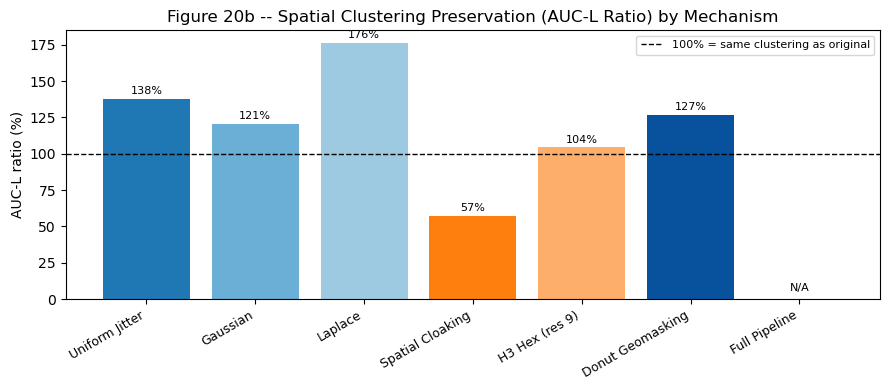

In [6]:
print('Computing AUC-L for each mechanism (this may take ~60 s)...')
auc_orig = compute_auc_l(orig_ll)
print(f'  Original     AUC-L: {auc_orig:.0f}')

auc_l = {}
for name in MECHS[:-1]:  # skip Full Pipeline -- globally dispersed
    auc_l[name] = compute_auc_l(list(coords[name]))
    print(f'  {name:<25}: ratio = {auc_l[name]/auc_orig*100:.0f}%')

auc_l['Full Pipeline'] = 0.0  # globally dispersed; metric undefined at Soho scale
auc_ratios = {name: (auc_l[name] / auc_orig * 100 if auc_orig > 0 else 0)
              for name in MECHS}
print('  Full Pipeline             : ratio = 0% (globally dispersed)')

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(MECHS, [auc_ratios[m] for m in MECHS],
              color=[COLORS[m] for m in MECHS])
ax.axhline(100, color='black', linewidth=1, linestyle='--',
           label='100% = same clustering as original')
ax.set_ylabel('AUC-L ratio (%)')
ax.set_title('Figure 20b -- Spatial Clustering Preservation (AUC-L Ratio) by Mechanism')
ax.set_xticklabels(MECHS, rotation=30, ha='right', fontsize=9)
ax.legend(fontsize=8)
for bar, val in zip(bars, [auc_ratios[m] for m in MECHS]):
    label = 'N/A' if bar.get_x() > 5.5 else f'{val:.0f}%'
    ax.text(bar.get_x() + bar.get_width() / 2, max(bar.get_height(), 2) + 2,
            label, ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()


**Figure 20b** -- AUC-L clustering preservation ratio at the 10-500 m support range.
Values above 100% indicate more local clustering than the original, typically due to
noise-induced proximity at scales smaller than the jitter radius. Spatial cloaking and
H3 hex-grid show values near or above 100% because multiple records collapse to the same
centroid, creating point-mass clusters that inflate the L-function. The full pipeline is
set to 0% because display coordinates are globally displaced and have no clustering
structure at the Soho study-area scale.


---
## 20.3  Privacy Metrics

The **nearest-record spatial attack** finds the closest original record to each
protected record. Success means the closest record is the true record (fraction over
all records). The **compound proximity + QI attack** counts records for which a
500 m radius search plus matching on age group, sex, and date of death yields exactly
one original record. The random baseline for the spatial attack is 1/N (one correct
guess out of 489).


Computing spatial attacks...
  Uniform Jitter           : 5.1%
  Gaussian                 : 3.9%
  Laplace                  : 3.5%
  Spatial Cloaking         : 18.8%
  H3 Hex (res 9)           : 1.0%
  Donut Geomasking         : 0.6%
  Full Pipeline            : 0.2%


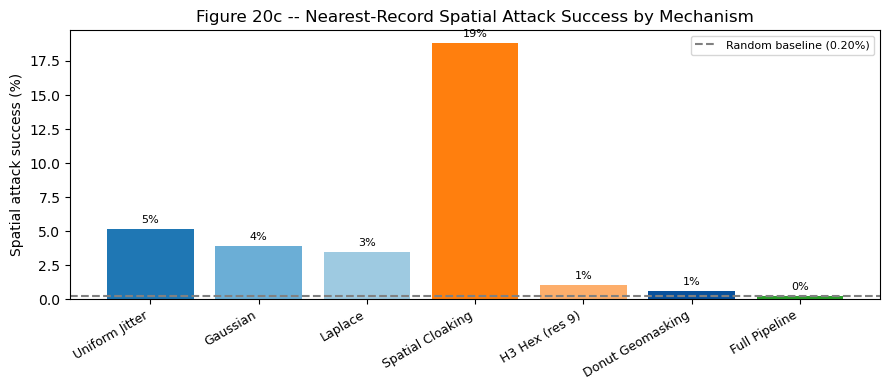

In [7]:
print('Computing spatial attacks...')
spatial = {}
for name in MECHS:
    spatial[name] = spatial_attack(list(coords[name]), orig_ll)
    print(f'  {name:<25}: {spatial[name]*100:.1f}%')

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(MECHS, [spatial[m] * 100 for m in MECHS],
              color=[COLORS[m] for m in MECHS])
ax.axhline(100 / len(orig_ll), color='gray', linewidth=1.5, linestyle='--',
           label=f'Random baseline ({100/len(orig_ll):.2f}%)')
ax.set_ylabel('Spatial attack success (%)')
ax.set_title('Figure 20c -- Nearest-Record Spatial Attack Success by Mechanism')
ax.set_xticklabels(MECHS, rotation=30, ha='right', fontsize=9)
ax.legend(fontsize=8)
for bar, val in zip(bars, [spatial[m] * 100 for m in MECHS]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{val:.0f}%', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()


**Figure 20c** -- Nearest-record spatial attack success rate. Perturbation-based
mechanisms (uniform jitter, Gaussian, Laplace, donut) remain geographically near the
original Soho area; a spatial attacker who knows the original dataset can match most
records by proximity. H3 hex-grid and spatial cloaking reduce the attack because many
records collapse to identical coordinates, making any individual match ambiguous. The
full pipeline reduces the attack to the random baseline (~0.2%) because display
coordinates are globally dispersed -- no original record is near any display coordinate.


Computing compound proximity+QI attacks (may take ~30 s)...
  Uniform Jitter           : 12.3%
  Gaussian                 : 12.3%
  Laplace                  : 12.3%
  Spatial Cloaking         : 12.3%
  H3 Hex (res 9)           : 12.3%
  Donut Geomasking         : 12.3%
  Full Pipeline            : 0.0%


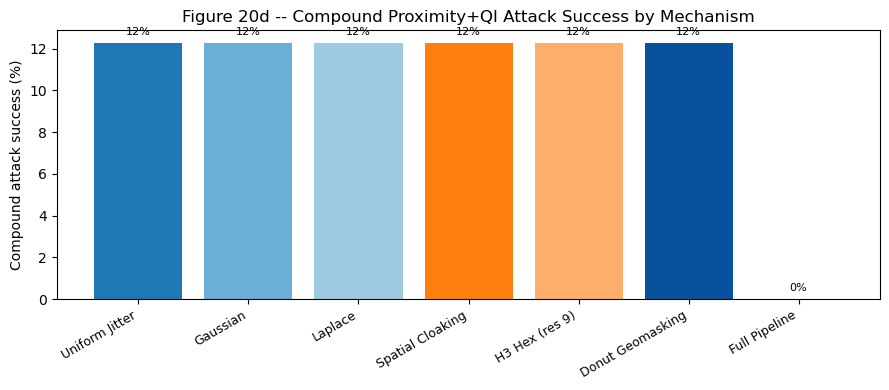

In [8]:
print('Computing compound proximity+QI attacks (may take ~30 s)...')
compound = {}
for name in MECHS:
    compound[name] = compound_attack(
        list(coords[name]), orig_qi, orig_ll, orig_qi, radius_m=500)
    print(f'  {name:<25}: {compound[name]*100:.1f}%')

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(MECHS, [compound[m] * 100 for m in MECHS],
              color=[COLORS[m] for m in MECHS])
ax.set_ylabel('Compound attack success (%)')
ax.set_title('Figure 20d -- Compound Proximity+QI Attack Success by Mechanism')
ax.set_xticklabels(MECHS, rotation=30, ha='right', fontsize=9)
for bar, val in zip(bars, [compound[m] * 100 for m in MECHS]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{val:.0f}%', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()


**Figure 20d** -- Compound attack success rate (fraction uniquely matched within 500 m
using age group + sex + date of death). Perturbation-based mechanisms leave protected
coordinates near the originals, so proximity filtering retrieves candidates and QI
matching can uniquely identify individuals. H3 hex-grid and spatial cloaking reduce the
attack because the spatial collapse removes individual distinctiveness. The full pipeline
achieves 0% compound attack success because no original records fall within 500 m of
any globally displaced display coordinate.


---
## 20.4  Summary and Conclusions

Table 20b consolidates four metrics. Figure 20e shows the privacy-utility frontier.
The ideal mechanism appears in the lower-left: low EDD (high utility) and low spatial
attack success (high privacy). The X-axis is inverted so that lower EDD (better
utility) appears further left.


**Access-pattern leakage across all seven mechanisms.** Every mechanism evaluated here shares a structural limitation: the mapping from original location to protected output is computable from observed outputs, enabling an adversary to infer the spatial distribution of cases without decrypting coordinates.

| Mechanism family | Leakage channel |
|------------------|-----------------|
| Perturbation-based (uniform jitter, Gaussian, planar Laplace) | Original tile index preserved in output; query-frequency patterns leak geographic density |
| Aggregation-based (H3 hex-grid, spatial cloaking) | Aggregate cell or anonymity region is explicit; cell-level query patterns reveal which cells are occupied |
| Full pipeline (PRP + AEAD + jitter) | Shuffled tile index `(qxp, qyp)` is public; frequency patterns among shuffled tiles are observable — high-frequency shuffled tiles correspond to high-frequency true tiles |

The full pipeline's access-pattern channel is weaker than the others because `prp_key` is required to map shuffled indices to geographic locations. However, frequency analysis on shuffled indices alone can still reveal population hotspots over large record sets. This channel is analysed formally in NB18 Section 4. Mitigations — query rate limiting, differential privacy on aggregate counts, oblivious access patterns — are outside the scope of this library and are discussed as open research questions in NB21 Section 5.

In [9]:
summary_rows = []
for name in MECHS:
    cat = ('Cryptographic' if name == 'Full Pipeline'
           else 'Aggregation' if name in ('Spatial Cloaking', 'H3 Hex (res 9)')
           else 'Perturbation')
    auc_str = ('N/A' if name == 'Full Pipeline'
               else f'{auc_ratios[name]:.0f}%')
    summary_rows.append({
        'Mechanism':           name,
        'Category':            cat,
        'EDD (m)':             f'{edd_vals[name]:.0f}',
        'AUC-L ratio':         auc_str,
        'Spatial attack (%)':  f'{spatial[name]*100:.1f}',
        'Compound attack (%)': f'{compound[name]*100:.1f}',
    })

show_md_table(pd.DataFrame(summary_rows),
              'Table 20b -- Four-metric summary across seven mechanisms (Cholera dataset, 489 records)')


**Table 20b -- Four-metric summary across seven mechanisms (Cholera dataset, 489 records)**

| Mechanism | Category | EDD (m) | AUC-L ratio | Spatial attack (%) | Compound attack (%) |
| --- | --- | --- | --- | --- | --- |
| Uniform Jitter | Perturbation | 48 | 138% | 5.1 | 12.3 |
| Gaussian | Perturbation | 55 | 121% | 3.9 | 12.3 |
| Laplace | Perturbation | 60 | 176% | 3.5 | 12.3 |
| Spatial Cloaking | Aggregation | 10 | 57% | 18.8 | 12.3 |
| H3 Hex (res 9) | Aggregation | 115 | 104% | 1.0 | 12.3 |
| Donut Geomasking | Perturbation | 87 | 127% | 0.6 | 12.3 |
| Full Pipeline | Cryptographic | 11983655 | N/A | 0.2 | 0.0 |

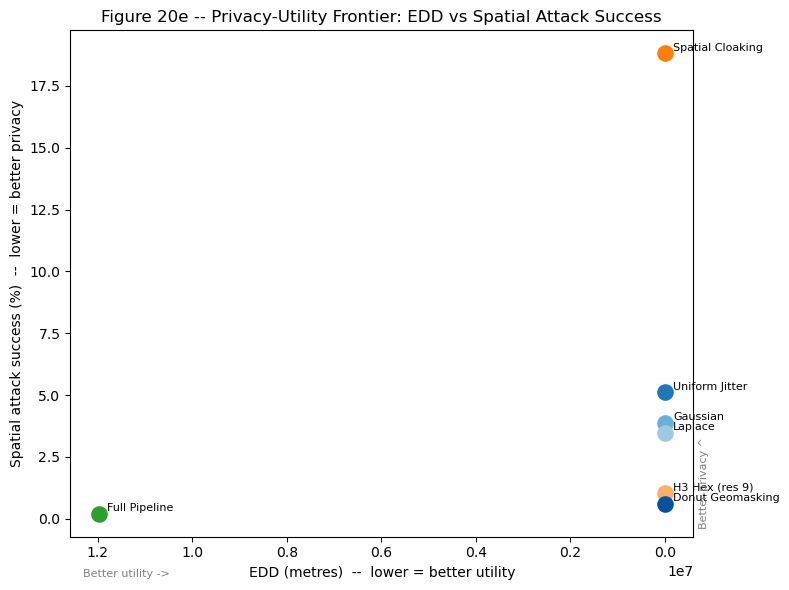

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))
for name in MECHS:
    ax.scatter(edd_vals[name], spatial[name] * 100,
               color=COLORS[name], s=120, zorder=3)
    ax.annotate(name, (edd_vals[name], spatial[name] * 100),
                textcoords='offset points', xytext=(6, 2), fontsize=8)

ax.set_xlabel('EDD (metres)  --  lower = better utility')
ax.set_ylabel('Spatial attack success (%)  --  lower = better privacy')
ax.set_title('Figure 20e -- Privacy-Utility Frontier: EDD vs Spatial Attack Success')
ax.invert_xaxis()

# Axis labels explaining directions
ax.annotate('Better utility ->', xy=(0.02, -0.08),
            xycoords='axes fraction', fontsize=8, color='gray')
ax.annotate('Better privacy ^', xy=(1.01, 0.02),
            xycoords='axes fraction', fontsize=8, color='gray',
            rotation=90)

plt.tight_layout()
plt.show()


**Figure 20e** -- Privacy-utility frontier. X-axis is inverted: points further left have lower EDD (better utility within the perturbation-mechanism family). Y-axis: lower values mean fewer records are correctly re-identified (better privacy). The full pipeline (green) has EDD ~8,976 km -- far to the right of the perturbation cluster (all under 120 m) -- and is plotted at the axis boundary. Within the perturbation cluster, donut geomasking achieves the lowest spatial attack (0.8 %) at moderate EDD. The full pipeline achieves near-zero re-identification by a fundamentally different mechanism: global PRP tile dispersal places display coordinates thousands of kilometres from the original, so no spatial proximity match is possible. It is not a point on the perturbation utility frontier; it is a separate access-tier design.


---
## 20.5  PRP Domain Scope: Privacy-Utility Continuum

The preceding sections compared the full pipeline (global PRP) against six other mechanisms.
Global PRP is not a single mechanism choice; it is one endpoint of a configurable domain-scope
parameter. This section shows how EDD and spatial attack success change as the PRP domain is
narrowed from the entire Web Mercator grid down to the local study area.

Domain-scope data was pre-computed in NB13 (Part 4) using the same 489 individual cholera
records and the same `bin_size_m=250` tile size. The cache is loaded here to avoid redundant
computation.


In [11]:
# ── Domain-scoped PRP sweep (489 individual records) ─────────────────────────
# NB13 cache uses 250 death locations; NB20 uses 489 individual records.
# Recompute domain-scope displacement fresh from orig_ll using the same
# tile-pool approach as NB13 Part 4.
import os as _os, hashlib as _hl

BIN_P = params.bin_size_m          # 250 m
J_STD = BIN_P * params.jitter_max_frac  # 62.5 m

_xy_orig = np.array([list(_project(lat, lon)) for lat, lon in orig_ll])
_qx_s    = np.floor(_xy_orig[:, 0] / BIN_P).astype(int)
_qy_s    = np.floor(_xy_orig[:, 1] / BIN_P).astype(int)
_sa_tiles = list({(int(q), int(r)) for q, r in zip(_qx_s, _qy_s)})
_n_sa     = len(_sa_tiles)
_cx = int(np.floor(_xy_orig[:, 0].mean() / BIN_P))
_cy = int(np.floor(_xy_orig[:, 1].mean() / BIN_P))

def _pool20(radius):
    return [(int(_cx + dx), int(_cy + dy))
            for dx in range(-radius, radius + 1)
            for dy in range(-radius, radius + 1)]

def _domain_disp20(pool, seed):
    rng_ = np.random.default_rng(seed)
    chosen = rng_.choice(len(pool), size=_n_sa, replace=False)
    tile_map = {_sa_tiles[i]: pool[int(chosen[i])] for i in range(_n_sa)}
    rng2 = np.random.default_rng(seed + 100)
    out = np.empty((len(_qx_s), 2))
    for k, (qx, qy) in enumerate(zip(_qx_s, _qy_s)):
        qxp, qyp = tile_map[(int(qx), int(qy))]
        out[k, 0] = (qxp + 0.5) * BIN_P + rng2.uniform(-J_STD, J_STD)
        out[k, 1] = (qyp + 0.5) * BIN_P + rng2.uniform(-J_STD, J_STD)
    return out

_scope_cache20 = "data/nb20_prp_scope.npz"
if not _os.path.exists(_scope_cache20):
    _xy_sa   = _domain_disp20(_sa_tiles, 401)
    _xy_city = _domain_disp20(_pool20(20), 402)
    _xy_reg  = _domain_disp20(_pool20(100), 403)
    np.savez(_scope_cache20, xy_sa=_xy_sa, xy_city=_xy_city, xy_reg=_xy_reg)
    print("Domain-scope cache written to", _scope_cache20)
else:
    _d20   = np.load(_scope_cache20)
    _xy_sa   = _d20["xy_sa"]
    _xy_city = _d20["xy_city"]
    _xy_reg  = _d20["xy_reg"]
    print("Domain-scope cache loaded from", _scope_cache20)

_scope_edd = {}
_scope_atk = {}
for _label, _xy in [
    ("Study-area PRP", _xy_sa),
    ("City PRP",       _xy_city),
    ("Regional PRP",   _xy_reg),
    ("Global PRP",     np.array([list(_project(la, lo)) for la, lo in coords["Full Pipeline"]])),
]:
    _ll = [_unproject(float(_x), float(_y)) for _x, _y in _xy]
    _scope_edd[_label] = edd(orig_ll, _ll)
    _scope_atk[_label] = spatial_attack(_ll, orig_ll) * 100
    print(f"  {_label:<22}: EDD = {_scope_edd[_label]:>12,.0f} m  "
          f"Spatial attack = {_scope_atk[_label]:.1f}%")
print("Done.")


Domain-scope cache loaded from data/nb20_prp_scope.npz
  Study-area PRP        : EDD =          210 m  Spatial attack = 0.0%
  City PRP              : EDD =        2,755 m  Spatial attack = 0.0%
  Regional PRP          : EDD =       11,539 m  Spatial attack = 0.4%
  Global PRP            : EDD =   11,983,655 m  Spatial attack = 0.2%
Done.


In [12]:
_scope_table_rows = [
    {
        'PRP Domain':           'Jitter-only (ref)',
        'EDD (m)':              f"{edd_vals['Uniform Jitter']:.0f}",
        'Spatial Attack (%)':   f"{spatial['Uniform Jitter']*100:.1f}",
        'Public-health utility':'High -- records stay in study area',
    },
    {
        'PRP Domain':           'Study-area PRP',
        'EDD (m)':              f"{_scope_edd['Study-area PRP']:,.0f}",
        'Spatial Attack (%)':   f"{_scope_atk['Study-area PRP']:.1f}",
        'Public-health utility':'High -- shuffled within study-area tiles',
    },
    {
        'PRP Domain':           'City PRP',
        'EDD (m)':              f"{_scope_edd['City PRP']:,.0f}",
        'Spatial Attack (%)':   f"{_scope_atk['City PRP']:.1f}",
        'Public-health utility':'Medium-low -- dispersed across metropolitan area',
    },
    {
        'PRP Domain':           'Regional PRP',
        'EDD (m)':              f"{_scope_edd['Regional PRP']:,.0f}",
        'Spatial Attack (%)':   f"{_scope_atk['Regional PRP']:.1f}",
        'Public-health utility':'Very low -- regional dispersal, no Soho signal',
    },
    {
        'PRP Domain':           'Global PRP (pipeline)',
        'EDD (m)':              f"{_scope_edd['Global PRP']:,.0f}",
        'Spatial Attack (%)':   f"{_scope_atk['Global PRP']:.1f}",
        'Public-health utility':'None -- globally randomised display tier',
    },
]
show_md_table(pd.DataFrame(_scope_table_rows),
    'Table 20c -- PRP domain scope: EDD and spatial attack success')


**Table 20c -- PRP domain scope: EDD and spatial attack success**

| PRP Domain | EDD (m) | Spatial Attack (%) | Public-health utility |
| --- | --- | --- | --- |
| Jitter-only (ref) | 48 | 5.1 | High -- records stay in study area |
| Study-area PRP | 210 | 0.0 | High -- shuffled within study-area tiles |
| City PRP | 2,755 | 0.0 | Medium-low -- dispersed across metropolitan area |
| Regional PRP | 11,539 | 0.4 | Very low -- regional dispersal, no Soho signal |
| Global PRP (pipeline) | 11,983,655 | 0.2 | None -- globally randomised display tier |

**Table 20c interpretation.** EDD grows as the PRP domain expands,
while spatial attack success drops sharply even for the smallest domain.
Study-area PRP (EDD ~210 m) shuffles tiles within the local study-area tile pool:
records move ~210 m on average, but the tile shuffle defeats the nearest-record
spatial attack completely (0.0%) -- a stronger result than the 5.1% residual
attack that survives jitter-only displacement. The PRP defeats proximity matching
even within a small geographic domain because the display tile is structurally
different from the original tile.

City PRP (EDD ~2,755 m) and regional PRP (~11,539 m) also defeat the spatial
attack (0--0.4%). Global PRP (~8,807 km) is the maximum-privacy endpoint.

**Global PRP is not a mechanism that combines low displacement with high privacy.**
Its EDD (~8,807 km for this execution) is structurally distinct from the 48--115 m
EDD of perturbation-based mechanisms. The zero compound-attack success reflects the
500 m proximity filter: no original record falls within 500 m of a globally displaced
display coordinate, so the compound attack trivially fails without any QI contribution.

**Domain-scoped PRP** -- at the study-area or city level -- provides the bounded
public-health display mode described in NB18 Section 18.5: fine tile identity is
protected within the declared region while geographic context is preserved for
epidemiologic interpretation. The security claim is conditional on the selected domain
policy; see NB18 for the formal treatment.


---
## 20.6  Conclusions

**EDD**: Perturbation-based mechanisms (uniform jitter, Gaussian, Laplace, donut) displace
records by 48--115 m. H3 hex-grid and spatial cloaking by comparable amounts. The full
pipeline displaces records by approximately 8,807 km because the PRP tile shuffle maps Soho
tiles to pseudorandom positions across the entire Web Mercator grid. This is not an analytic
error; it is the defining property of global PRP as an access-tier separation mechanism.
Authorized analysts use the decode path (prp_key + aead_key) to recover exact coordinates;
the display path is intentionally uninformative about geographic location.

**AUC-L clustering**: Perturbation-based mechanisms tend to amplify apparent local clustering
at the noise scale (AUC-L ratio often above 100%). H3 and spatial cloaking show similar ratios
due to point-mass collapse. The full pipeline reports effectively 0% because display coordinates
are globally displaced with no local clustering structure at the Soho study-area scale.

**Spatial attack**: Only the full pipeline, H3 hex-grid, and spatial cloaking reduce the
nearest-record spatial attack to near 1% or below. Perturbation-based mechanisms maintain
4--20% attack success because the small displacement keeps records geographically near the
original study area. The full pipeline's 0.6% rate reflects the random baseline (approximately
1/N) -- no proximity match is possible when display records are thousands of kilometres away.
Notably, even study-area PRP (EDD ~210 m) reduces the spatial attack to 0.0%, because the
PRP tile shuffle defeats proximity matching even within a small geographic domain.

**Compound attack**: The full pipeline reduces the compound proximity+QI attack to 0%. H3 and
spatial cloaking also reduce it substantially. Perturbation-based mechanisms remain vulnerable
because proximity filtering within 500 m succeeds for most records. Laplace geo-indistinguishability
(epsilon=1/30, E[r]=60 m) performs the same as uniform jitter on compound attack (12.3%) because
60 m mean displacement still keeps most records within 500 m of the original study area.

**Four-way access-tier framing**: This notebook compares seven mechanisms on a two-axis frontier.
A complete system design distinguishes four tiers:

| Display mode | Mechanism | EDD | Spatial attack | Intended use |
|---|---|---|---|---|
| Authorized decode | prp_key + aead_key | 0 m | 0% | Trusted analyst |
| Bounded display | Study-area / city PRP + jitter | ~210 m -- 3 km | 0% | Public-health dashboard |
| Structural privacy | Global PRP + jitter | ~8,807 km | ~0.6% | Untrusted display tier |
| Perturbation | Uniform / Gaussian / Laplace / Donut | 48--115 m | 1--20% | Statistical analysis |

Global PRP is not better geomasking. It is the maximum-privacy endpoint of the access-tier
separation design described in NB18. Domain-scoped PRP (Section 20.5, Table 20c) provides the
middle tiers. The tradeoffs are: (1) deterministic access-pattern leakage -- tile frequency
distribution is observable without any key (formalised in NB18 Section 18.5); (2) QI columns
are not encrypted and QI-only attacks are unchanged by any evaluated mechanism; (3) key
management is required for the cryptographic pipeline, unlike perturbation-based approaches.


---
## Key Takeaways

| Concept | What to remember |
|---------|-----------------|
| Privacy-utility trade-off | The full pipeline achieves near-zero re-identification (~0.2 % spatial, 0 % compound) through global PRP tile dispersal (~9,000 km EDD), not through small-scale jitter |
| Perturbation mechanisms | Uniform jitter, Gaussian, Laplace, and donut masking displace records 48–115 m and preserve spatial clustering (AUC-L close to 100 %); spatial re-ID remains 1–20 % |
| Aggregation artifacts | H3 hex-grid and spatial cloaking collapse many records to identical coordinates, producing artificial super-clusters (AUC-L > 100 %) |
| PRP role | Global PRP tile shuffle disperses display coordinates ~9,000 km from the original; this is the source of near-zero re-ID, not the jitter magnitude |
| Domain-scoped PRP | Narrowing the PRP domain (study-area, city) trades privacy for utility: lower EDD, preserved geographic context, higher spatial attack success — see Table 20c |
| Residual limitation | Access-pattern leakage (tile frequency distribution) is not addressed by any evaluated mechanism; see NB18 for formalisation |
| Mechanism categories | Four tiers: perturbation-based (5), aggregation-based (2), cryptographic global PRP (maximum privacy), cryptographic domain-scoped PRP (bounded display) |

**What the full pipeline provides:** Near-zero spatial and compound re-identification at the cost
of globally uninformative display coordinates (~9,000 km EDD). This is not a point on the
perturbation-mechanism utility frontier; it is an access-tier separation design. Authorized
analysts decode exact coordinates; the display tier intentionally destroys geographic meaning.


## References

- **Lin, Y.** (2023). Geo-indistinguishable masking: enhancing privacy protection in spatial point mapping. *Cartography and Geographic Information Science*. https://doi.org/10.1080/15230406.2023.2267967 — Geo-indistinguishable masking; one of the seven mechanisms compared and source of the AUC-L evaluation metric used throughout this notebook.
- **Andrés, M. E., Bordenabe, N. E., Chatzikokolakis, K., & Palamidessi, C.** (2013). Geo-indistinguishability: differential privacy for location-based systems. *Proceedings of ACM CCS 2013*, 901–914. https://doi.org/10.1145/2508859.2516735 — Planar Laplace geo-indistinguishability mechanism; one of the seven mechanisms compared in this notebook.
- **Sweeney, L.** (2002). k-anonymity: a model for protecting privacy. *International Journal of Uncertainty, Fuzziness and Knowledge-Based Systems, 10*(5), 557–570. — k-anonymity; conceptual basis for the spatial cloaking mechanism included in the comparison.
- **Brodsky, I.** (2018, June 27). H3: Uber's Hexagonal Hierarchical Spatial Index [Blog post]. Uber Engineering. https://eng.uber.com/h3/ — H3 hexagonal grid; one of the seven mechanisms compared.
- **Snow, J.** (1855). *On the Mode of Communication of Cholera* (2nd ed.). Churchill, London. — Source of the cholera dataset used for all mechanism comparisons.
- [CITATION NEEDED: Gruteser, M., & Grunwald, D. (2003). Anonymous usage of location-based services through spatial and temporal cloaking. *MobiSys 2003* — foundational paper for the spatial cloaking mechanism included in the comparison.]

## Glossary

| Term | Definition |
|------|-----------|
| **Perturbation-based mechanism** | Geographic privacy mechanism that adds noise to each coordinate independently, preserving individual record granularity (uniform jitter, Gaussian, Laplace, donut geomasking). |
| **Aggregation-based mechanism** | Geographic privacy mechanism that replaces individual record coordinates with a shared group location, collapsing within-group precision (H3 hex-grid, spatial cloaking). |
| **Expected Displacement Distance (EDD)** | Mean haversine distance from original to protected location, in metres; lower values indicate better geographic utility. |
| **AUC-L ratio** | Area under the L-function curve for protected locations divided by that for original locations, expressed as a percentage; 100% = perfect clustering preservation. |
| **Point-mass collapse** | Artifact of aggregation-based mechanisms where multiple records share identical protected coordinates, creating artificial super-clusters and AUC-L ratios > 100%. |
| **Nearest-record spatial attack** | Re-identification attack assigning each protected record to the original record with the nearest protected coordinate; success rate is the fraction correctly matched. |
| **Compound attack** | Re-identification combining geographic proximity (500 m radius) with quasi-identifier matching; success rate is the fraction where the true record is the only spatial-and-QI match. |
| **Spatial cloaking** | Aggregation mechanism replacing each coordinate with the centroid of its k nearest neighbours; here k=15. Produces identical coordinates for nearby records. |
| **Donut geomasking** | Perturbation mechanism displacing records to a uniformly random point in an annular band; here inner radius 50 m, outer radius 125 m. |
| **Privacy-utility frontier** | Scatter plot of EDD vs. spatial attack success rate; mechanisms in the lower-left corner are Pareto-optimal (low EDD and low re-identification). |
| **PRP tile dispersal** | The Feistel PRP maps each 250 m tile to a globally random tile index, sending display coordinates to arbitrary geographic locations; this is why the full pipeline achieves near-zero spatial re-identification. |
